# Tune Layer Validation

Focused checks for `tune.py` and the DataFrame-backed tune plotting helpers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

from tune import (
    build_tune_programme_table,
    build_working_point_table,
    evaluate_resonance_proximity,
    extract_tune_summary,
    generate_resonance_lines,
    make_tune_diagram_inputs,
)
from tune_plots import (
    plot_resonance_working_points,
    plot_tune_diagram_inputs,
)

## Summary extraction

In [2]:
summary = {"q1": 4.331, "q2": 3.731, "dq1": 0.12, "dq2": -0.08}
compact = extract_tune_summary(summary, source="dict")
assert compact == {
    "qx": 4.331,
    "qy": 3.731,
    "dqx": 0.12,
    "dqy": -0.08,
    "source": "dict",
}

summary_df = pd.DataFrame([{
    "actual_qx": 4.320,
    "actual_qy": 3.720,
    "actual_dqx": 0.10,
    "actual_dqy": -0.06,
}])
compact_df = extract_tune_summary(summary_df)
assert compact_df["qx"] == 4.320
assert compact_df["qy"] == 3.720
assert compact_df["dqx"] == 0.10
assert compact_df["dqy"] == -0.06
compact_df


{'qx': 4.32, 'qy': 3.72, 'dqx': 0.1, 'dqy': -0.06, 'source': None}

## Programme and working-point tables

In [3]:
time_array = np.array([
    -0.1, 0.0, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
    5.5, 6.0, 7.0, 8.0, 9.0, 10.0,
])
qx_array = np.array([
    4.315, 4.270, 4.270, 4.250, 4.235, 4.205,
    4.170, 4.190, 4.180, 4.180, 4.180, 4.170,
    4.165, 4.165, 4.165, 4.180, 4.180, 4.175,
])
qy_array = np.array([
    3.820, 3.820, 3.810, 3.805, 3.800, 3.825,
    3.680, 3.680, 3.690, 3.700, 3.700, 3.695,
    3.695, 3.695, 3.692, 3.690, 3.685, 3.665,
])
predicted_qx_array = np.array([
    4.301189, 4.255937, 4.256764, 4.241837, 4.235257, 4.220856,
    4.214514, 4.235361, 4.238186, 4.245530, 4.252191, 4.254271,
    4.257571, 4.261834, 4.268251, 4.276188, 4.278320, 4.278037,
])
predicted_qy_array = np.array([
    3.856601, 3.854470, 3.842348, 3.832849, 3.822817, 3.836668,
    3.732895, 3.735702, 3.743759, 3.750365, 3.751709, 3.751012,
    3.752133, 3.753054, 3.753594, 3.754034, 3.753386, 3.748840,
])

raw_programme = pd.DataFrame({
    "cycle_time_ms": time_array,
    "qx": qx_array,
    "qy": qy_array,
    "predicted_qx": predicted_qx_array,
    "predicted_qy": predicted_qy_array,
})

programme = build_tune_programme_table(raw_programme, source="copied_full_cycle_machine_tunes")
required_programme_columns = {
    "cycle_time_ms", "set_qx", "set_qy", "predicted_qx", "predicted_qy",
    "actual_qx", "actual_qy", "matched_qx", "matched_qy", "dqx", "dqy", "iqtf_A", "iqtd_A",
    "kqtf", "kqtd", "source",
}
assert required_programme_columns.issubset(programme.columns)
assert len(programme) == len(time_array) == len(qx_array) == len(qy_array)
assert programme["source"].eq("copied_full_cycle_machine_tunes").all()
assert np.allclose(programme["cycle_time_ms"], time_array)
assert np.allclose(programme["set_qx"], qx_array)
assert np.allclose(programme["set_qy"], qy_array)
assert np.allclose(programme["predicted_qx"], predicted_qx_array)
assert np.allclose(programme["predicted_qy"], predicted_qy_array)
assert np.allclose(programme["actual_qx"], predicted_qx_array)
assert np.allclose(programme["actual_qy"], predicted_qy_array)

working_points = build_working_point_table(programme)
assert {"predicted_minus_set_qx", "predicted_minus_set_qy"}.issubset(working_points.columns)
assert np.allclose(working_points["predicted_minus_set_qx"], predicted_qx_array - qx_array)
assert np.allclose(working_points["predicted_minus_set_qy"], predicted_qy_array - qy_array)
assert np.allclose(working_points["actual_minus_set_qx"], predicted_qx_array - qx_array)
assert np.allclose(working_points["actual_minus_set_qy"], predicted_qy_array - qy_array)
working_points

,index,cycle_time_ms,set_qx,set_qy,predicted_qx,predicted_qy,actual_qx,actual_qy,matched_qx,matched_qy,predicted_minus_set_qx,predicted_minus_set_qy,actual_minus_set_qx,actual_minus_set_qy,matched_minus_set_qx,matched_minus_set_qy,source
0,0,-0.1,4.315,3.820,4.301189,3.856601,4.301189,3.856601,None,None,-0.013811,0.036601,-0.013811,0.036601,None,None,copied_full_cycle_machine_tunes
1,1,0.0,4.270,3.820,4.255937,3.854470,4.255937,3.854470,None,None,-0.014063,0.034470,-0.014063,0.034470,None,None,copied_full_cycle_machine_tunes
2,2,0.5,4.270,3.810,4.256764,3.842348,4.256764,3.842348,None,None,-0.013236,0.032348,-0.013236,0.032348,None,None,copied_full_cycle_machine_tunes
3,3,1.0,4.250,3.805,4.241837,3.832849,4.241837,3.832849,None,None,-0.008163,0.027849,-0.008163,0.027849,None,None,copied_full_cycle_machine_tunes
4,4,1.5,4.235,3.800,4.235257,3.822817,4.235257,3.822817,None,None,0.000257,0.022817,0.000257,0.022817,None,None,copied_full_cycle_machine_tunes
5,5,2.0,4.205,3.825,4.220856,3.836668,4.220856,3.836668,None,None,0.015856,0.011668,0.015856,0.011668,None,None,copied_full_cycle_machine_tunes
6,6,2.5,4.170,3.680,4.214514,3.732895,4.214514,3.732895,None,None,0.044514,0.052895,0.044514,0.052895,None,None,copied_full_cycle_machine_tunes
7,7,3.0,4.190,3.680,4.235361,3.735702,4.235361,3.735702,None,None,0.045361,0.055702,0.045361,0.055702,None,None,copied_full_cycle_machine_tunes
8,8,3.5,4.180,3.690,4.238186,3.743759,4.238186,3.743759,None,None,0.058186,0.053759,0.058186,0.053759,None,None,copied_full_cycle_machine_tunes
9,9,4.0,4.180,3.700,4.245530,3.750365,4.245530,3.750365,None,None,0.065530,0.050365,0.065530,0.050365,None,None,copied_full_cycle_machine_tunes


## Resonance lines and proximity

In [4]:
resonance_df = generate_resonance_lines(
    xlims=(4.0, 4.5),
    ylims=(3.5, 4.0),
    orders=(1, 2, 3, 4),
    periodicity=10,
)
assert not resonance_df.empty
assert {
    "order", "nx", "ny", "resonance_sum", "systematic",
    "x0", "y0", "x1", "y1", "label",
}.issubset(resonance_df.columns)
assert resonance_df["x0"].between(4.0, 4.5).all()
assert resonance_df["x1"].between(4.0, 4.5).all()
assert resonance_df["y0"].between(3.5, 4.0).all()
assert resonance_df["y1"].between(3.5, 4.0).all()

proximity = evaluate_resonance_proximity(
    working_points,
    resonance_lines=resonance_df,
    qx_column="predicted_qx",
    qy_column="predicted_qy",
)
assert len(proximity) == len(working_points)
assert np.isfinite(proximity["absolute_distance"]).all()
proximity

,point_index,cycle_time_ms,qx,qy,nearest_order,nearest_nx,nearest_ny,nearest_resonance_sum,nearest_label,nearest_systematic,signed_distance,absolute_distance
0,0,-0.1,4.301189,3.856601,3,1,2,12,1Qx + 2Qy = 12,False,0.006436,0.006436
1,1,0.0,4.255937,3.854470,4,4,0,17,4Qx + 0Qy = 17,False,0.005937,0.005937
2,2,0.5,4.256764,3.842348,4,4,0,17,4Qx + 0Qy = 17,False,0.006764,0.006764
3,3,1.0,4.241837,3.832849,4,4,0,17,4Qx + 0Qy = 17,False,-0.008163,0.008163
4,4,1.5,4.235257,3.822817,4,4,0,17,4Qx + 0Qy = 17,False,-0.014743,0.014743
5,5,2.0,4.220856,3.836668,4,4,0,17,4Qx + 0Qy = 17,False,-0.029144,0.029144
6,6,2.5,4.214514,3.732895,4,1,-3,-7,1Qx - 3Qy = -7,False,0.005006,0.005006
7,7,3.0,4.235361,3.735702,4,2,-2,1,2Qx - 2Qy = 1,False,-0.000241,0.000241
8,8,3.5,4.238186,3.743759,4,1,-3,-7,1Qx - 3Qy = -7,False,0.002185,0.002185
9,9,4.0,4.245530,3.750365,4,0,-4,-15,0Qx - 4Qy = -15,False,-0.000365,0.000365


## Tune diagram plotting

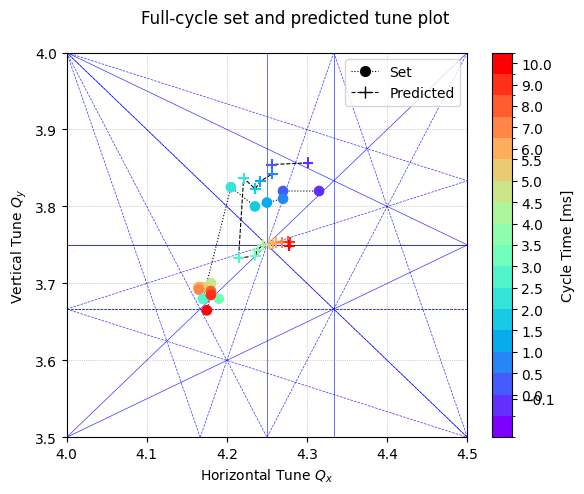

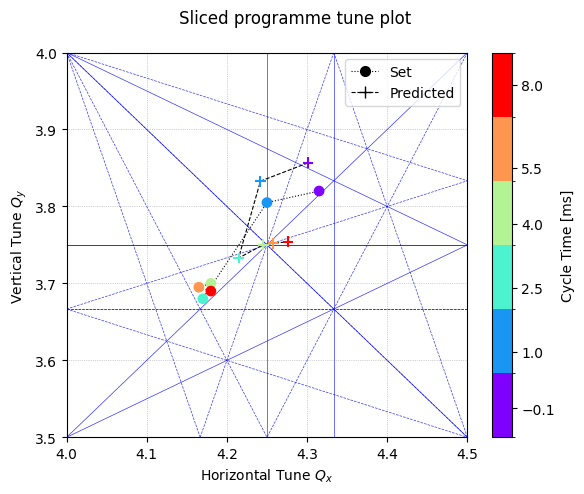

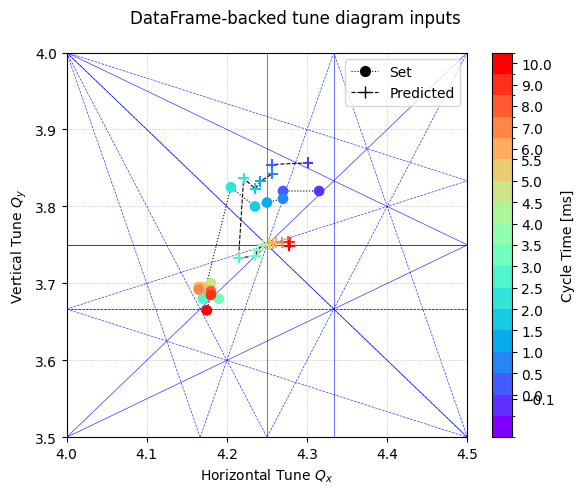

In [5]:
diagram_inputs = make_tune_diagram_inputs(
    programme,
    xlims=(4.0, 4.5),
    ylims=(3.5, 4.0),
    proximity_qx_column="predicted_qx",
    proximity_qy_column="predicted_qy",
)
fig_cycle, ax_cycle = plot_resonance_working_points(
    programme,
    xlims=(4.0, 4.5),
    ylims=(3.5, 4.0),
)
fig_cycle.suptitle("Full-cycle set and predicted tune plot")
display(fig_cycle)
assert fig_cycle is ax_cycle.figure
plt.close(fig_cycle)

fig_slice, ax_slice = plot_resonance_working_points(
    programme.iloc[::3],
    xlims=(4.0, 4.5),
    ylims=(3.5, 4.0),
)
fig_slice.suptitle("Sliced programme tune plot")
display(fig_slice)
assert fig_slice is ax_slice.figure
plt.close(fig_slice)

fig_inputs, ax_inputs = plot_tune_diagram_inputs(diagram_inputs)
fig_inputs.suptitle("DataFrame-backed tune diagram inputs")
display(fig_inputs)
assert fig_inputs is ax_inputs.figure
plt.close(fig_inputs)